# Phishing Email Detection with BERT
## Notebook 06 – Synthetic Evaluation and Threshold Analysis

This notebook evaluates the phishing email classifier on a synthetic or derived
evaluation dataset. It focuses on measuring performance, visualizing predictions,
and analyzing how different decision thresholds affect classification behavior.


### Notebook objectives

- Load a synthetic or pre-generated evaluation dataset for the phishing detector.
- Run the fine-tuned BERT model to obtain logits, probabilities, and predictions.
- Compute detailed evaluation metrics and classification reports.
- Visualize confusion matrices and other diagnostic plots.
- Explore and analyze the impact of decision thresholds on model behaviour.


### 1. Imports and configuration

Import core libraries for model loading, evaluation, plotting, and file handling,
and prepare any paths or constants needed for synthetic evaluation.


In [14]:
import os, re, html, base64
from pathlib import Path
from typing import List, Optional
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from pathlib import Path


### 2. Paths, columns, and decision thresholds

Set model/dataset paths and define thresholds for phishing vs. benign classification.


In [2]:

MODEL_DIR = Path("../models/saved_model")
SYNTHETIC_PATH = Path("../data/SyntheticEmails.csv")

TEXT_COL = "text"
LABEL_COL = "label"

OUTPUT_PATH = Path("../analysis/synthetic_predictions.csv")

THRESH_PHISH = 0.90
THRESH_HAM   = 0.30

LABELS = {0: "benign", 1: "phishing"}


### 3. Text normalization utilities

Clean and normalize raw email text for BERT preprocessing.


In [3]:

# Normalize punct spacing for urls
def normalize_punct_spacing_for_urls(s: str) -> str:
    s = str(s)
    s = re.sub(r'(?i)([a-z0-9])((?:https?|ftp|file))', r'\1 \2', s)
    s = re.sub(r'\s*\.\s*', '.', s)
    s = re.sub(r'\s*/\s*', '/', s)
    s = re.sub(r'\s*:\s*', ':', s)
    s = re.sub(
        r'\b(?:h\s*t\s*t\s*p(?:s)?)\b',
        lambda m: m.group(0).replace(' ', ''),
        s,
        flags=re.IGNORECASE,
    )
    s = re.sub(
        r'\b(?:f\s*t\s*p)\b',
        lambda m: m.group(0).replace(' ', ''),
        s,
        flags=re.IGNORECASE,
    )
    s = re.sub(
        r'(?i)\b(https?|ftp|file)\s*[\.:;]\s*/\s*/',
        r'\1://',
        s,
    )
    return s

# Clean text
def clean_text_for_bert(text: str) -> str:
    if text is None:
        return ""
    text = html.unescape(str(text))
    text = normalize_punct_spacing_for_urls(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


### 4. Load and clean synthetic evaluation data

Import the synthetic dataset, combine subject and body, clean the text, and remove empty entries.


In [4]:

if not SYNTHETIC_PATH.exists():
    raise FileNotFoundError(f"Synthetic file not found: {SYNTHETIC_PATH}")

df_syn = pd.read_csv(SYNTHETIC_PATH)

required_cols = ["subject", "body"]
for col in required_cols:
    if col not in df_syn.columns:
        raise ValueError(f"Column '{col}' not found in CSV. Available columns: {list(df_syn.columns)}")

print(f"Loaded {len(df_syn)} synthetic emails from {SYNTHETIC_PATH}")

df_syn["text"] = (df_syn["subject"].astype(str) + " " + df_syn["body"].astype(str)).str.strip()

df_syn["text_clean"] = df_syn["text"].apply(clean_text_for_bert)

before = len(df_syn)
df_syn = df_syn[df_syn["text_clean"].str.len() > 0].reset_index(drop=True)
print(f"Kept {len(df_syn)}/{before} rows after removing empty texts.")


Loaded 2000 synthetic emails from ../data/SyntheticEmails.csv
Kept 2000/2000 rows after removing empty texts.


### 5. Load model and tokenizer

Load the saved classifier and move it to the appropriate device for evaluation.


In [5]:

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

try:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, local_files_only=True)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_DIR, local_files_only=True
    ).to(device)
except Exception as e:
    print("Local load failed with:", repr(e))
    tokenizer = AutoTokenizer.from_pretrained(str(MODEL_DIR))
    model = AutoModelForSequenceClassification.from_pretrained(str(MODEL_DIR)).to(device)

model.eval()


Using device: cuda


2025-12-05 19:57:13.455819: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-05 19:57:13.527265: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-05 19:57:15.909621: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.3098949027144738, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.3098949027144738, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerN

### 6. Compute phishing probabilities for synthetic dataset

Batch-score all cleaned synthetic texts and record their phishing probabilities.


In [6]:

@torch.inference_mode()

# Score texts
def score_texts(text_list, batch_size: int = 32):
    probs_phish = []

    for i in tqdm(range(0, len(text_list), batch_size), desc="Scoring synthetic emails"):
        batch_texts = text_list[i : i + batch_size]

        enc = tokenizer(
            batch_texts,
            truncation=True,
            max_length=512,
            padding=True,
            return_tensors="pt",
        )

        enc = {k: v.to(device) for k, v in enc.items()}

        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=-1)
        batch_p_phish = probs[:, 1].cpu().numpy().tolist()
        probs_phish.extend(batch_p_phish)

    return probs_phish

df_syn["p_phish"] = score_texts(df_syn["text_clean"].tolist())
print("Finished scoring; p_phish column created.")
print(df_syn[["text_clean", "p_phish"]].head())


Scoring synthetic emails: 100%|█████████████████████████████████████████████████████████| 63/63 [00:11<00:00,  5.53it/s]

Finished scoring; p_phish column created.
                                          text_clean   p_phish
0  Weekly status update Dear Valued Member, Here ...  0.029502
1  Unusual activity detected on your account Hell...  0.999857
2  Team meeting on Thursday at 11:00 AM Hello Val...  0.000997
3  A document has been shared with you via Accoun...  0.999802
4  Newsletter:Recent news and updates Dear Custom...  0.036577


### 7. Threshold-based classification

Translate phishing probabilities into Ham / Phishing / Uncertain labels and class indices.


In [7]:

# Classify probability
def classify_probability(p: float) -> str:
    if p >= THRESH_PHISH:
        return "Phishing"
    if p <= THRESH_HAM:
        return "Ham"
    return "Uncertain"

df_syn["pred_label"] = df_syn["p_phish"].apply(classify_probability)

df_syn["pred_class_idx"] = (df_syn["p_phish"] >= 0.5).astype(int)
df_syn["pred_class_name"] = df_syn["pred_class_idx"].map(LABELS)

df_syn.head()


,label,subject,body,text,text_clean,p_phish,pred_label,pred_class_idx,pred_class_name
0,benign,Weekly status update,"Dear Valued Member,\n\nHere is the weekly stat...","Weekly status update Dear Valued Member,\n\nHe...","Weekly status update Dear Valued Member, Here ...",0.029502,Ham,0,benign
1,phishing,Unusual activity detected on your account,"Hello Customer,\n\nWe identified activity on y...",Unusual activity detected on your account Hell...,Unusual activity detected on your account Hell...,0.999857,Phishing,1,phishing
2,benign,Team meeting on Thursday at 11:00 AM,"Hello Valued Member,\n\nThis is a reminder abo...",Team meeting on Thursday at 11:00 AM Hello Val...,Team meeting on Thursday at 11:00 AM Hello Val...,0.000997,Ham,0,benign
3,phishing,A document has been shared with you via Accoun...,"Hi Valued Member,\n\nHR Coordinator has shared...",A document has been shared with you via Accoun...,A document has been shared with you via Accoun...,0.999802,Phishing,1,phishing
4,benign,Newsletter: Recent news and updates,"Dear Customer,\n\nWelcome to this month's news...",Newsletter: Recent news and updates Dear Custo...,Newsletter:Recent news and updates Dear Custom...,0.036577,Ham,0,benign


### 8. Evaluation metrics

Map true labels to numeric form and compute precision, recall, and F1 scores.


In [15]:

if LABEL_COL is not None and LABEL_COL in df_syn.columns:

    y_true_raw = df_syn[LABEL_COL].astype(str).str.strip().str.lower()

    label_map = {
        "benign": 0,
        "phishing": 1,
    }

    y_true = y_true_raw.map(label_map).astype(int)

    y_pred = df_syn["pred_class_idx"]

    accuracy  = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall    = recall_score(y_true, y_pred)
    f1        = f1_score(y_true, y_pred)
    
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")

else:
    print(f"No usable LABEL_COL ('{LABEL_COL}') found. Skipping metrics.")


Accuracy:  0.8425
Precision: 0.7605
Recall:    1.0000
F1-score:  0.8639


### 9. Confusion matrix visualization

Plot and save raw and normalized confusion matrices for synthetic predictions.


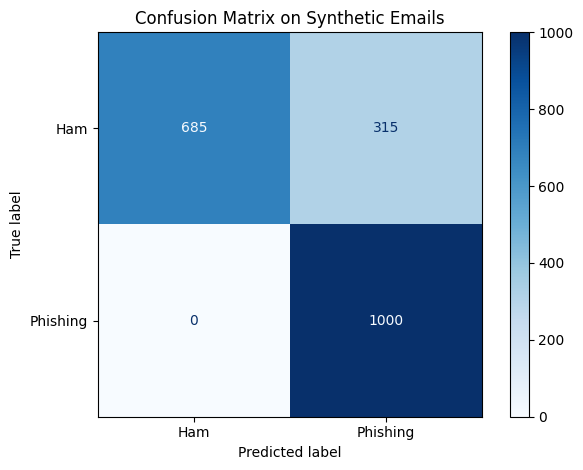

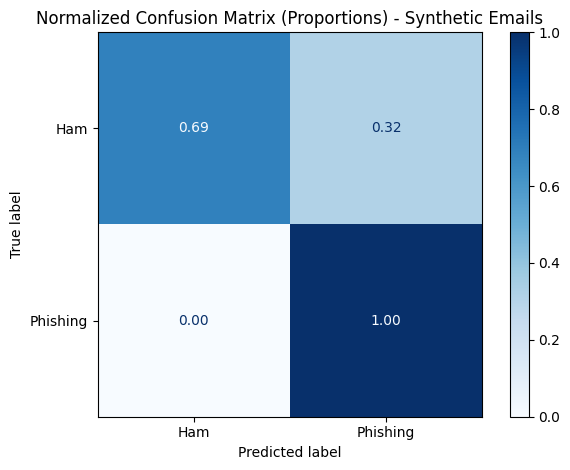

In [12]:

label_order = [0, 1]
disp_names = ["Ham", "Phishing"]

cm = confusion_matrix(y_true, y_pred, labels=label_order)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=disp_names)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix on Synthetic Emails")
plt.tight_layout()
plt.savefig("confusion_matrix_synthetic_raw.png",
            bbox_inches="tight", dpi=300)
plt.show()
plt.close()

cm_norm = confusion_matrix(y_true, y_pred,
                           labels=label_order, normalize="true")

disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                              display_labels=disp_names)
disp.plot(cmap="Blues", values_format=".2f")
plt.title("Normalized Confusion Matrix (Proportions) - Synthetic Emails")
plt.tight_layout()
plt.savefig("confusion_matrix_synthetic_normalized.png",
            bbox_inches="tight", dpi=300)
plt.show()
plt.close()


### 10. Export results

Save the synthetic evaluation predictions to CSV.


In [11]:

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df_syn.to_csv(OUTPUT_PATH, index=False, encoding="utf-8")
print(f"Saved synthetic predictions to {OUTPUT_PATH}")


Saved synthetic predictions to ../analysis/synthetic_predictions.csv
